In [1]:
import json
import numpy as np
import ast
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from metrics_clean import compute_zadu_metrics
from utils import get_pareto_front, render_policy
import os

/Users/zuzannaosika/miniforge3/envs/env_py11/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## Load all the data

### Load cheetah

In [2]:
#get trajectories for morld from json files
#only if they end with .json
returns = get_pareto_front("trajectories/morld/mo-halfcheetah-v4_100steps", pareto_size=80)
all_t_emb_e200 = []
path=f'trajectories/morld/mo-halfcheetah-v4_100steps/embeddings/mo-halfcheetah-v4_100steps_3D_l2_embeddings_e250_two_t_ts100_shorter.json'
with open(path, "r") as f:
    embedding = json.load(f)
for policy in embedding:
    t_emb = np.array(policy['T_Embedding'])
    all_t_emb_e200.append(t_emb)

all_t_emb_cheetah = np.array(all_t_emb_e200)



### Load highway

In [3]:


returns_highway = get_pareto_front("trajectories/morld/mo-highway-fast-v0_100steps_test", pareto_size=41)
all_t_emb_e200 = []
path=f'trajectories/morld/mo-highway-fast-v0_100steps_test/embeddings/mo-highway-fast-v0_100steps_3D_l6_embeddings_e100_two_t_shorter.json'
with open(path, "r") as f:
    embedding = json.load(f)
for policy in embedding:
    t_emb = np.array(policy['T_Embedding'])
    all_t_emb_e200.append(t_emb)

all_t_emb_high = np.array(all_t_emb_e200)



## Trustworthiness and Continuity

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

print("\n--- RAW METRICS ---")
print("Returns vs highway embedding:", compute_zadu_metrics(returns_highway, all_t_emb_high))
print(" Returns vs cheeta embedding:", compute_zadu_metrics(returns, all_t_emb_cheetah))




--- RAW METRICS ---
ZADU metrics computed successfully
Returns vs highway embedding: [{'trustworthiness': 0.6565853658536585, 'continuity': 0.6588617886178862}, {'mrre_false': 0.6523356758991318, 'mrre_missing': 0.6568830095080612}]
ZADU metrics computed successfully
 Returns vs cheeta embedding: [{'trustworthiness': 0.9494281045751635, 'continuity': 0.9633169934640524}, {'mrre_false': 0.9402127659574468, 'mrre_missing': 0.9568617021276594}]


### Visualize embeddings

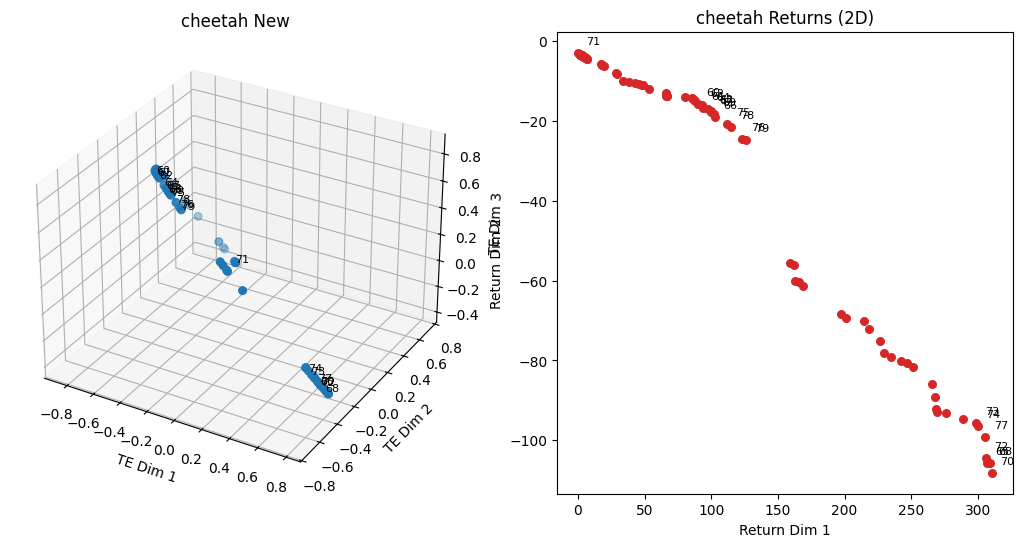

In [5]:
# Full visualization: 3D TE (e100), 2D Returns, 3D TE (e200).
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ensure arrays
returns = np.asarray(returns)
all_t_e100 = np.asarray(all_t_emb_cheetah)


# indices to annotate (original indices) — adjust as needed
start, end = 60, 79
sel = np.arange(start, end + 1)
sel = sel[sel < len(returns)]

fig = plt.figure(figsize=(20, 6))

# TE E100 3D (all points)
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(all_t_e100[:, 0], all_t_e100[:, 1], all_t_e100[:, 2], c='tab:blue', s=30)
ax1.set_title('cheetah New ')
ax1.set_xlabel('TE Dim 1'); ax1.set_ylabel('TE Dim 2'); ax1.set_zlabel('TE Dim 3')
# annotate only selected indices
for idx in sel:
    if idx < len(all_t_e100):
        x, y, z = all_t_e100[idx]
        ax1.text(x, y, z, str(int(idx)), fontsize=8, color='k')

# Returns 2D (all points)
ax2 = fig.add_subplot(132)
ax2.scatter(returns[:, 0], returns[:, 1], c='tab:red', s=30)
ax2.set_title('cheetah Returns (2D)')
ax2.set_xlabel('Return Dim 1'); ax2.set_ylabel('Return Dim 2')
# compute small offset based on data span
if returns.shape[1] >= 2:
    dx = np.ptp(returns[:, 0]) * 0.02 if np.ptp(returns[:, 0]) > 0 else 0.01
    dy = np.ptp(returns[:, 1]) * 0.02 if np.ptp(returns[:, 1]) > 0 else 0.01
else:
    dx = dy = 0.01
for idx in sel:
    if idx < len(returns):
        x, y = returns[idx, 0], returns[idx, 1]
        ax2.text(x + dx, y + dy, str(int(idx)), fontsize=8, color='k')



In [28]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# --- assume you already have these numpy arrays ---
# returns: shape (N, 2)
# embeddings: shape (N, 3) or (N, D)
# example for testing:
# returns = np.random.rand(50, 2)
# embeddings = np.random.rand(50, 3)

# --- Sort lexicographically and keep mapping ---
sort_idx = np.lexsort(returns.T)
sorted_pf = returns[sort_idx]

# --- Build dataframe ---
df = pd.DataFrame({
    "obj1": sorted_pf[:, 0],
    "obj2": sorted_pf[:, 1],
    "rank": np.arange(len(sort_idx)),     # new ordered index
    "orig_idx": sort_idx                  # original index
})

# --- 2D Pareto frontier visualization ---
fig2d = go.Figure()

fig2d.add_trace(go.Scatter(
    x=df["obj1"],
    y=df["obj2"],
    mode="markers+text",
    text=df["rank"].astype(str),
    textposition="top center",
    marker=dict(size=8, color="crimson"),
    customdata=np.stack([df["rank"], df["orig_idx"]], axis=-1),
    hovertemplate=(
        "new idx (rank)=%{customdata[0]}<br>"
        "original idx=%{customdata[1]}<br>"
        "obj1=%{x:.3f}<br>"
        "obj2=%{y:.3f}<extra></extra>"
    ),
    name="Pareto (sorted)"
))

fig2d.update_layout(
    width=800, height=600,
    title="Sorted Pareto Frontier (labels = new ordered indices)",
    xaxis_title="Objective 1",
    yaxis_title="Objective 2"
)

fig2d.write_html("cheetah.html")
fig2d.show()


# --- 3D embeddings visualization aligned with sorted indices ---
emb3 = all_t_e100[:, :3]           # take first 3 dims if more
emb3_sorted = emb3[sort_idx]       # reorder same as returns

fig3d = go.Figure()

# points labeled by new sorted index
fig3d.add_trace(go.Scatter3d(
    x=emb3_sorted[:, 0],
    y=emb3_sorted[:, 1],
    z=emb3_sorted[:, 2],
    mode="markers+text",
    text=df["rank"].astype(str),
    textposition="top center",
    marker=dict(
        size=4,
        color=df["rank"],
        colorscale="Viridis",
        colorbar=dict(title="rank")
    ),
    customdata=np.stack([df["rank"], df["orig_idx"]], axis=-1),
    hovertemplate=(
        "new idx (rank)=%{customdata[0]}<br>"
        "original idx=%{customdata[1]}<br>"
        "x=%{x:.3f}<br>"
        "y=%{y:.3f}<br>"
        "z=%{z:.3f}<extra></extra>"
    ),
    name="Embeddings (sorted)"
))


fig3d.update_layout(
    width=900, height=700,
    title="3D Embeddings (aligned with sorted Pareto indices)",
    scene=dict(
        xaxis_title="Embedding dim 1",
        yaxis_title="Embedding dim 2",
        zaxis_title="Embedding dim 3"
    )
)

fig3d.write_html("cheetah_3d_embeddings.html")
fig3d.show()


## Lipschitz Histograms


Computing Lipschitz constant between policy 0 and 1
0.49369822280726416
3.803333410695175e-05
Lipshitz: 7.703761599684683e-05
Lipschitz constant for policy 0 ([ 8.0787637   6.42188975 -0.83230635], [ 0.11956719  0.64006537 -0.75895983]) to 1 ([ 7.6109274   6.57808988 -0.81065795], [ 0.11953793  0.64008605 -0.75894707]): 7.703761599684683e-05, d_obj: 0.49369822280726416, d_emb: 3.803333410695175e-05
Computing Lipschitz constant between policy 1 and 2
1.2207629144267582
2.43578156729967e-06
Lipshitz: 1.9952945314065804e-06
Lipschitz constant for policy 1 ([ 7.6109274   6.57808988 -0.81065795], [ 0.11953793  0.64008605 -0.75894707]) to 2 ([ 6.50084346  6.07040909 -0.79529741], [ 0.11953609  0.64008737 -0.75894618]): 1.9952945314065804e-06, d_obj: 1.2207629144267582, d_emb: 2.43578156729967e-06
Computing Lipschitz constant between policy 2 and 3
0.8172593704075668
0.00014331167143021392
Lipshitz: 0.00017535641268786489
Lipschitz constant for policy 2 ([ 6.50084346  6.07040909 -0.79529741],

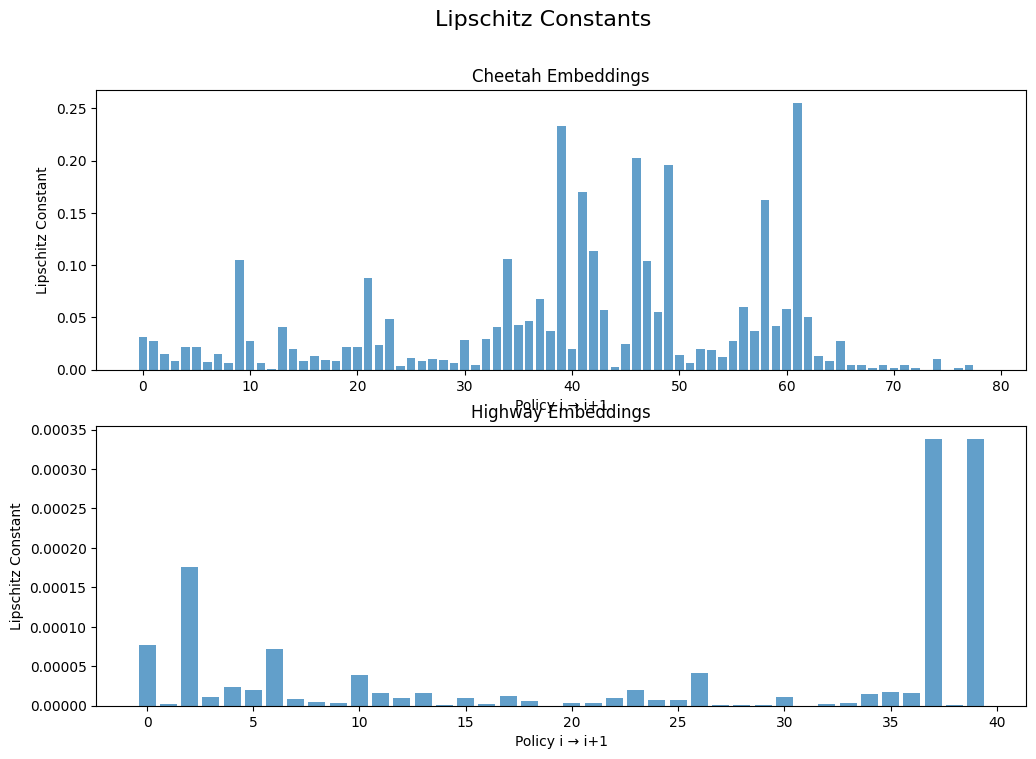

In [7]:
# Makes a histogram of the Lipschitz constants of the GTE embeddings vs the returns

# Compute Lipschitz constants
def compute_lipschitz_constants(pareto_frontier: np.ndarray, embeddings: np.ndarray, normalize = False) -> np.ndarray:
    """
    Compute pairwise Lipschitz constants between consecutive points
    in the Pareto frontier and embedding space.

    Args:
        pareto_frontier: (n_points, d_obj) array of objective values
        embeddings: (n_points, d_emb) array of embeddings

    Returns:
        lipschitz_constants: (n_points-1,) array of Lipschitz constants
    """
    # Lexicographic sort: np.lexsort expects keys in reverse order
    sort_idx = np.lexsort(pareto_frontier.T)
    sorted_pf = pareto_frontier[sort_idx]
    sorted_emb = embeddings[sort_idx]

    if normalize:
        #Normalize sorted pf to range [-1,1]
        scaler_pf = MinMaxScaler(feature_range=(-1, 1))
        sorted_pf = scaler_pf.fit_transform(sorted_pf)



    lipschitz_constants = []
    for i in range(len(sorted_pf) - 1):
        print(f"Computing Lipschitz constant between policy {i} and {i+1}")
        d_obj = np.linalg.norm(sorted_pf[i+1] - sorted_pf[i])
        print(d_obj)
        d_emb = np.linalg.norm(sorted_emb[i+1] - sorted_emb[i])
        print(d_emb)
        lipschitz_constants.append(d_emb / d_obj)
        print(f'Lipshitz: {d_emb/d_obj}')

        print(f"Lipschitz constant for policy {i} ({sorted_pf[i]}, {sorted_emb[i]}) to {i+1} ({sorted_pf[i+1]}, {sorted_emb[i+1]}): {lipschitz_constants[-1]}, d_obj: {d_obj}, d_emb: {d_emb}")

    return np.array(lipschitz_constants)



lipschitz_constants_highway = compute_lipschitz_constants(pareto_frontier=returns_highway, embeddings=all_t_emb_high)
lipschitz_constants_cheetah = compute_lipschitz_constants(pareto_frontier=returns, embeddings=all_t_emb_cheetah)



import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(2, figsize=(12, 8))

# --- Plot 1: Left-Right ---
fig.suptitle("Lipschitz Constants ", fontsize=16)
axs[0].bar(np.arange(len(lipschitz_constants_cheetah)), lipschitz_constants_cheetah, alpha=0.7)
axs[0].set_title("Cheetah Embeddings")
axs[0].set_ylabel("Lipschitz Constant")
axs[0].set_xlabel("Policy i → i+1")

axs[1].bar(np.arange(len(lipschitz_constants_highway)), lipschitz_constants_highway, alpha=0.7)
axs[1].set_title("Highway Embeddings")
axs[1].set_ylabel("Lipschitz Constant")
axs[1].set_xlabel("Policy i → i+1")



plt.show()





## Cheetah analysis

In [ ]:
#get policies with the highest lipshitz jump
import numpy as np
sorted_idx = np.argsort(lipschitz_constants_cheetah)
highest_pairs  = [[f, f+1]for f in sorted_idx[-2:]]
highest_pairs
org_policy_id =  np.lexsort(returns.T)[highest_pairs[-1]]
render_policy(env_id="mo-halfcheetah-v4", check_point="MORL_policies/morld_cheetah_v5/seed0.tar", policy_id=org_policy_id[0], n_episodes=5, save_dic="videos/half-cheetah/highest")
render_policy(env_id="mo-halfcheetah-v4", check_point="MORL_policies/morld_cheetah_v5/seed0.tar", policy_id=org_policy_id[1], n_episodes=5, save_dic="videos/half-cheetah/highest")


array([33, 32])

In [ ]:
#Get policies with the  secondhighest Lipschitz constants
import numpy as np
sorted_idx = np.argsort(lipschitz_constants_cheetah)
highest_pairs  = [[f, f+1]for f in sorted_idx[-2:]]
highest_pairs[-1]
#see what policies these correspond to in the original pareto front
org_policy_id =  np.lexsort(returns.T)[highest_pairs[-2]]
render_policy(env_id="mo-halfcheetah-v4", check_point="MORL_policies/morld_cheetah_v5/seed0.tar", policy_id=org_policy_id[0], n_episodes=5, save_dic="videos/half-cheetah/second_highest")
render_policy(env_id="mo-halfcheetah-v4", check_point="MORL_policies/morld_cheetah_v5/seed0.tar", policy_id=org_policy_id[1], n_episodes=5, save_dic="videos/half-cheetah/second_highest")

Weights: [[0.         1.        ]
 [0.19917259 0.80082741]
 [0.39978924 0.60021076]
 [0.60048042 0.39951958]
 [0.80099882 0.19900118]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]
[MORLD] mo-halfcheetah-v4: rendering policy 60 with weights [0.19917259 0.80082741]
Weights: [[0.         1.        ]
 [0.19917259 0.80082741]
 [0.39978924 0.60021076]
 [0.60048042 0.39951958]
 [0.80099882 0.19900118]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]
[MORLD] mo-halfcheetah-v4: rendering policy 59 with weights [0.19917259 0.80082741]


## Highway analysis

In [ ]:
#Get policies with the highest Lipschitz constants
import numpy as np
sorted_idx = np.argsort(lipschitz_constants_highway)
highest_pairs  = [[f, f+1]for f in sorted_idx[-2:]]
highest_pairs[-1]
#see what policies these correspond to in the original pareto front
org_policy_id =  np.lexsort(returns_highway.T)[highest_pairs[-1]]
render_policy(env_id="mo-highway-fast-v0", check_point="MORL_policies/mo-highway-fast-v0/seed0.tar", policy_id=org_policy_id[0], n_episodes=5, save_dic="videos/highway/highest")
render_policy(env_id="mo-highway-fast-v0", check_point="MORL_policies/mo-highway-fast-v0/seed0.tar", policy_id=org_policy_id[1], n_episodes=5, save_dic="videos/highway/highest")

array([23,  9])

In [ ]:
#Get policies with the highest Lipschitz constants
import numpy as np
sorted_idx = np.argsort(lipschitz_constants_highway)
highest_pairs  = [[f, f+1]for f in sorted_idx[-2:]]
highest_pairs[-1]
#see what policies these correspond to in the original pareto front
org_policy_id =  np.lexsort(returns_highway.T)[highest_pairs[-2]]
render_policy(env_id="mo-highway-fast-v0", check_point="MORL_policies/mo-highway-fast-v0/seed0.tar", policy_id=org_policy_id[0], n_episodes=5, save_dic="videos/highway/second_highest")
render_policy(env_id="mo-highway-fast-v0", check_point="MORL_policies/mo-highway-fast-v0/seed0.tar", policy_id=org_policy_id[1], n_episodes=5, save_dic="videos/highway/second_highest")

/Users/zuzannaosika/miniforge3/envs/env_py11/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/zuzannaosika/miniforge3/envs/env_py11/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Weights: [[0.  0.  1. ]
 [0.  0.5 0.5]
 [0.  1.  0. ]
 [0.5 0.  0.5]
 [0.5 0.5 0. ]
 [1.  0.  0. ]]
Neighborhoods: [[1], [0], [1], [0], [1], [3]]
[MORLD] mo-highway-fast-v0: rendering policy 23 with weights [0. 1. 0.]


/Users/zuzannaosika/miniforge3/envs/env_py11/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/zuzannaosika/miniforge3/envs/env_py11/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Weights: [[0.  0.  1. ]
 [0.  0.5 0.5]
 [0.  1.  0. ]
 [0.5 0.  0.5]
 [0.5 0.5 0. ]
 [1.  0.  0. ]]
Neighborhoods: [[1], [0], [1], [0], [1], [3]]
[MORLD] mo-highway-fast-v0: rendering policy 9 with weights [0. 1. 0.]
